## Generate input images for abberation-resilience testing of CFCNN

* In this notebook, we define the tested range of aberrations and use them to generate star-pattern images.
* Here we assume strong signals, i.e., virtually noiseless images.
* We study astigmatism, coma, defocus, and spherical aberration.
* Resulting images are saved in `data/` and subsequently processed by `process_inputs_cnn.py`
* PSF model is defined in `psf_toolbox_v2.py`

In [73]:
import numpy as np
from numpy.fft import fftshift, ifft2, ifftshift
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import h5py
from tqdm import tqdm
import tifffile
from psf_toolbox_v2 import psf_high_NA_vector, render_psf_emitters
from tqdm import tqdm

# Fix random number generator for repeatable executions
RNG = np.random.default_rng(seed=20250113)
cwl = 580 #nm
au = 0.61*cwl/1.4 #airy unit in nm


In [74]:
def upscale_xyi(xyi, scale=4):
    """
    Upscales the x and y coordinates of a list of [x, y, i] elements by a given scale factor.

    This function takes a list of [x, y, i] elements, where x and y are coordinates and i is an 
    additional value, and scales the x and y coordinates by the specified scale factor. A shift 
    is applied to center the scaled coordinates.

    Args:
        xyi (list of lists or tuples): A list of [x, y, i] elements to be upscaled.
        scale (int, optional): The scale factor to upscale the x and y coordinates. Defaults to 4.

    Returns:
        list: A list of upscaled [x, y, i] elements with the same structure as the input.
    """
    xyiarr = np.array(xyi)
    shift = int((scale-1)/2) #this is intentional
    xyiarr[:, 0] = xyiarr[:, 0]*scale + shift
    xyiarr[:, 1] = xyiarr[:, 1]*scale + shift
    return list(xyiarr)
    
def generate_image(xyi, noise_mean, noise_std, h, w, norm=False, **aber_kwargs):
    """
    Generates a 2D image with Gaussian point sources and added noise.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains 
            (x, y, intensity) representing the coordinates and intensity 
            of a point source.
        noise_mean (float): The mean of the Gaussian noise to be added to the image.
        noise_std (float): The standard deviation of the Gaussian noise.
        psf_width (float): The width of the point spread function (PSF) for the Gaussian sources.
        h (int): The height of the generated image.
        w (int): The width of the generated image.

    Returns:
        numpy.ndarray: A 2D array representing the generated image, normalized 
        such that all pixel values sum to 1.
    """
    # img = np.clip(RNG.normal(noise_mean, noise_std,
    #               h*w).reshape(h, w), 0, None)
    img0 = RNG.normal(noise_mean, noise_std,
                   h*w).reshape(h, w)    
    au = 580*0.61/1.4
    psfhr_x, x, y = psf_high_NA_vector(256, 16, 0.580, 1.4, 1.5, 'x', **aber_kwargs)
    psfhr_y, x, y = psf_high_NA_vector(256, 16, 0.580, 1.4, 1.5, 'y', **aber_kwargs)
    psfhr = (psfhr_x + psfhr_y)*0.5
    psfhr = psfhr[2048-64 : 2048+64, 2048-64: 2048+64]
    psfhr /= np.max(psfhr)

    img_em = render_psf_emitters(xyi, 59/au, psfhr, 0.125/2, 50, 50)
    img = img0 + np.random.poisson(img_em)
    if not norm:
        return img
    return img/np.sum(img)

def l1norm(img):
    img = (img - np.min(img))
    return img/np.sum(img)

def generate_gt_image(xyi, h, w):
    """
    Generate a ground truth image by placing intensities at specified coordinates.

    Args:
        xyi (list of tuples): A list of tuples where each tuple contains three values 
                              (x, y, intensity). `x` and `y` are the coordinates, and 
                              `intensity` is the value to be added at that position.
        h (int): The height of the output image.
        w (int): The width of the output image.

    Returns:
        numpy.ndarray: A 2D array of shape (h, w) representing the generated image, 
                       normalized such that the sum of all pixel values equals 1.

    Notes:
        - The function rounds the `x` and `y` coordinates to the nearest integer 
          to determine the pixel location.
        - If the rounded coordinates fall outside the image dimensions, they are ignored.
        - The resulting image is normalized by dividing all pixel values by the total sum.
    """
    img = np.zeros((h, w))
    for x, y, intensity in xyi:
        x_nearest = int(np.round(x))
        y_nearest = int(np.round(y))
        if (x_nearest <= w-1) and (y_nearest <= h-1):
            img[y_nearest, x_nearest] += intensity
    return img/np.sum(img)

## Reference: aberration-free star

In [75]:
MONTE_CARLO_SAMPLES = 1

WIDTH = 50
HEIGTH = 50
BCKG = 0
UPSCALE = 4
DEG = np.pi/180.
THETA_STEP = 45*DEG
snrs = 1_000_000
snrs_mc = np.ones(MONTE_CARLO_SAMPLES)*snrs
noise_std = 0

params = {'width' : WIDTH, 'height' : HEIGTH, 'upscale' : UPSCALE, 'noise_std_scale' : noise_std, 'mc_samples' : MONTE_CARLO_SAMPLES}

# Generate coordinates of the star-shaped pattern.
xys = np.array([(25, 25)]+[(r*np.cos(THETA_STEP*i)+25, r*np.sin(THETA_STEP*i)+25)
               for i in range(8) for r in [6, 12, 18]])
xys = np.round(xys)
# Save the pattern parameters into numpy file.
np.savez('star_truth_info_new_star.npz', snrs=snrs_mc, xys=xys)

def add_snr_col(snr):
    """Add third column with SNR to an array of coordinates."""
    n = xys.shape[0]
    return np.hstack([xys, np.ones((n, 1))*snr])


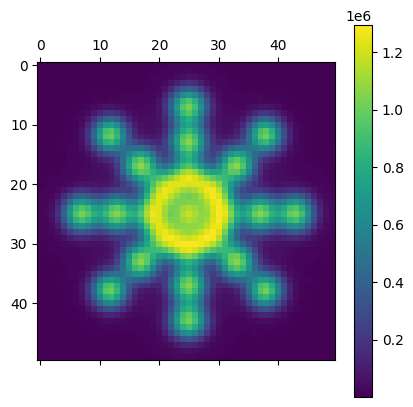

In [102]:
plt.matshow(generate_image(add_snr_col(1_000_000), BCKG, 0, HEIGTH, WIDTH, A_def = 0.0))
plt.colorbar()
plt.show()

In [79]:
num_psfs = 30
abberations = {
    'A_coma_x' :  np.linspace(0.0, 0.3, num_psfs),
    'A_ast' : np.linspace(0.0, 0.3, num_psfs),
    'A_sph' : np.linspace(0.0, 0.3, num_psfs),    
    'A_def' : np.linspace(0.0, 0.3, num_psfs)
}

## Generate star-pattern for all tested aberrations

In [80]:
snr = snrs
stacks = {}
for key, _params in abberations.items():    
    stacks[key] = np.array([generate_image(add_snr_col(snr), 0, 0, HEIGTH, WIDTH, **{key : p}) for p in tqdm(_params)])


100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [06:52<00:00, 13.74s/it]

100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [06:52<00:00, 13.75s/it]

100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [06:52<00:00, 13.75s/it]

100%|███████████████████████████████████████████████████████████████████████████████████| 30/30 [06:52<00:00, 13.75s/it]


In [ ]:
##################################################################################

[[101. 101.  10.]
 [125. 101.  10.]
 [149. 101.  10.]
 [173. 101.  10.]
 [117. 117.  10.]
 [133. 133.  10.]
 [153. 153.  10.]
 [101. 125.  10.]
 [101. 149.  10.]
 [101. 173.  10.]
 [ 85. 117.  10.]
 [ 69. 133.  10.]
 [ 49. 153.  10.]
 [ 77. 101.  10.]
 [ 53. 101.  10.]
 [ 29. 101.  10.]
 [ 85.  85.  10.]
 [ 69.  69.  10.]
 [ 49.  49.  10.]
 [101.  77.  10.]
 [101.  53.  10.]
 [101.  29.  10.]
 [117.  85.  10.]
 [133.  69.  10.]
 [153.  49.  10.]]


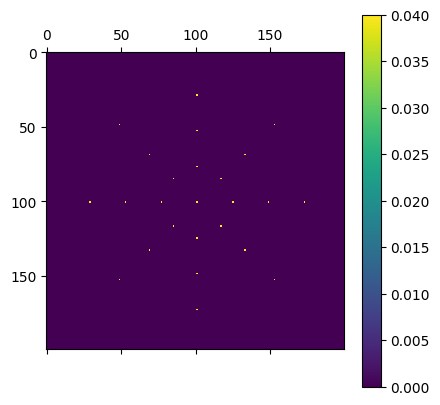

In [103]:
# Generate reference image

xyi = np.array(upscale_xyi(add_snr_col(10), scale=UPSCALE))
xyi.shape
print(xyi)
gtim = generate_gt_image(xyi, HEIGTH*UPSCALE, WIDTH*UPSCALE)
gtim.shape
plt.matshow(gtim)
plt.colorbar()

In [95]:
params = {'width' : WIDTH, 'height' : HEIGTH, 'upscale' : UPSCALE, 'noise_std_scale' : noise_std, 'mc_samples' : MONTE_CARLO_SAMPLES}

In [99]:
key = 'star_vs_snr'
dsets_ref = dict()
dsets_inp = dict()
# dsets_ref[key] = np.copy(stack_noiseless)
dsets_inp[key] = np.copy(stack_for_cnn)

with h5py.File('data/input_for_cnn_star_w_psfs.h5', 'w') as h5f:        
    h5f.create_dataset('reference', data=gtim, dtype=np.float32)
    dset_ref_pos = h5f.create_dataset('reference_pos', data=xys)
    dset_snrs = h5f.create_dataset('snrs', data=snrs_mc, dtype=np.float32)
    for key, aber_range in abberations.items():
        print(key)
        dset_aber_range = h5f.create_dataset(f'param_{key}', data=aber_range)
        dset_imgs = h5f.create_dataset(key, data=np.array([l1norm(img) for img in stacks[key]]))
    for pkey, val in params.items():
        print(pkey)
        h5f.attrs.create(f'gen_params_{pkey}', val)


A_coma_x
A_ast
A_sph
A_def
width
height
upscale
noise_std_scale
mc_samples


Now one would execute script `process_inputs_cnn.py`.